# Chargement du dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Charger le Dataset
dataset_path='Acoustic_Extinguisher_Fire_Dataset.csv'
data = pd.read_csv(dataset_path)


# Exploration

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  object 
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   CLASS      17442 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 954.0+ KB


In [3]:
data.isnull().sum()

SIZE         0
FUEL         0
DISTANCE     0
DESIBEL      0
AIRFLOW      0
FREQUENCY    0
CLASS        0
dtype: int64

In [4]:
data.describe(include="all")

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,CLASS
count,17442.000000,17442,17442.000000,17442.000000,17442.000000,17442.000000,17442.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,gasoline,NaN,NaN,NaN,NaN,NaN
freq,NaN,5130,NaN,NaN,NaN,NaN,NaN
mean,3.411765,NaN,100.000000,96.379142,6.975634,31.611111,0.497821
std,1.750977,NaN,54.773826,8.164096,4.736169,20.939149,0.500010
min,1.000000,NaN,10.000000,72.000000,0.000000,1.000000,0.000000
25%,2.000000,NaN,50.000000,90.000000,3.200000,14.000000,0.000000
50%,3.000000,NaN,100.000000,95.000000,5.800000,27.500000,0.000000
75%,5.000000,NaN,150.000000,104.000000,11.200000,47.000000,1.000000


In [5]:
data.duplicated().sum()

0

In [6]:
data["CLASS"].value_counts()

CLASS
0    8759
1    8683
Name: count, dtype: int64

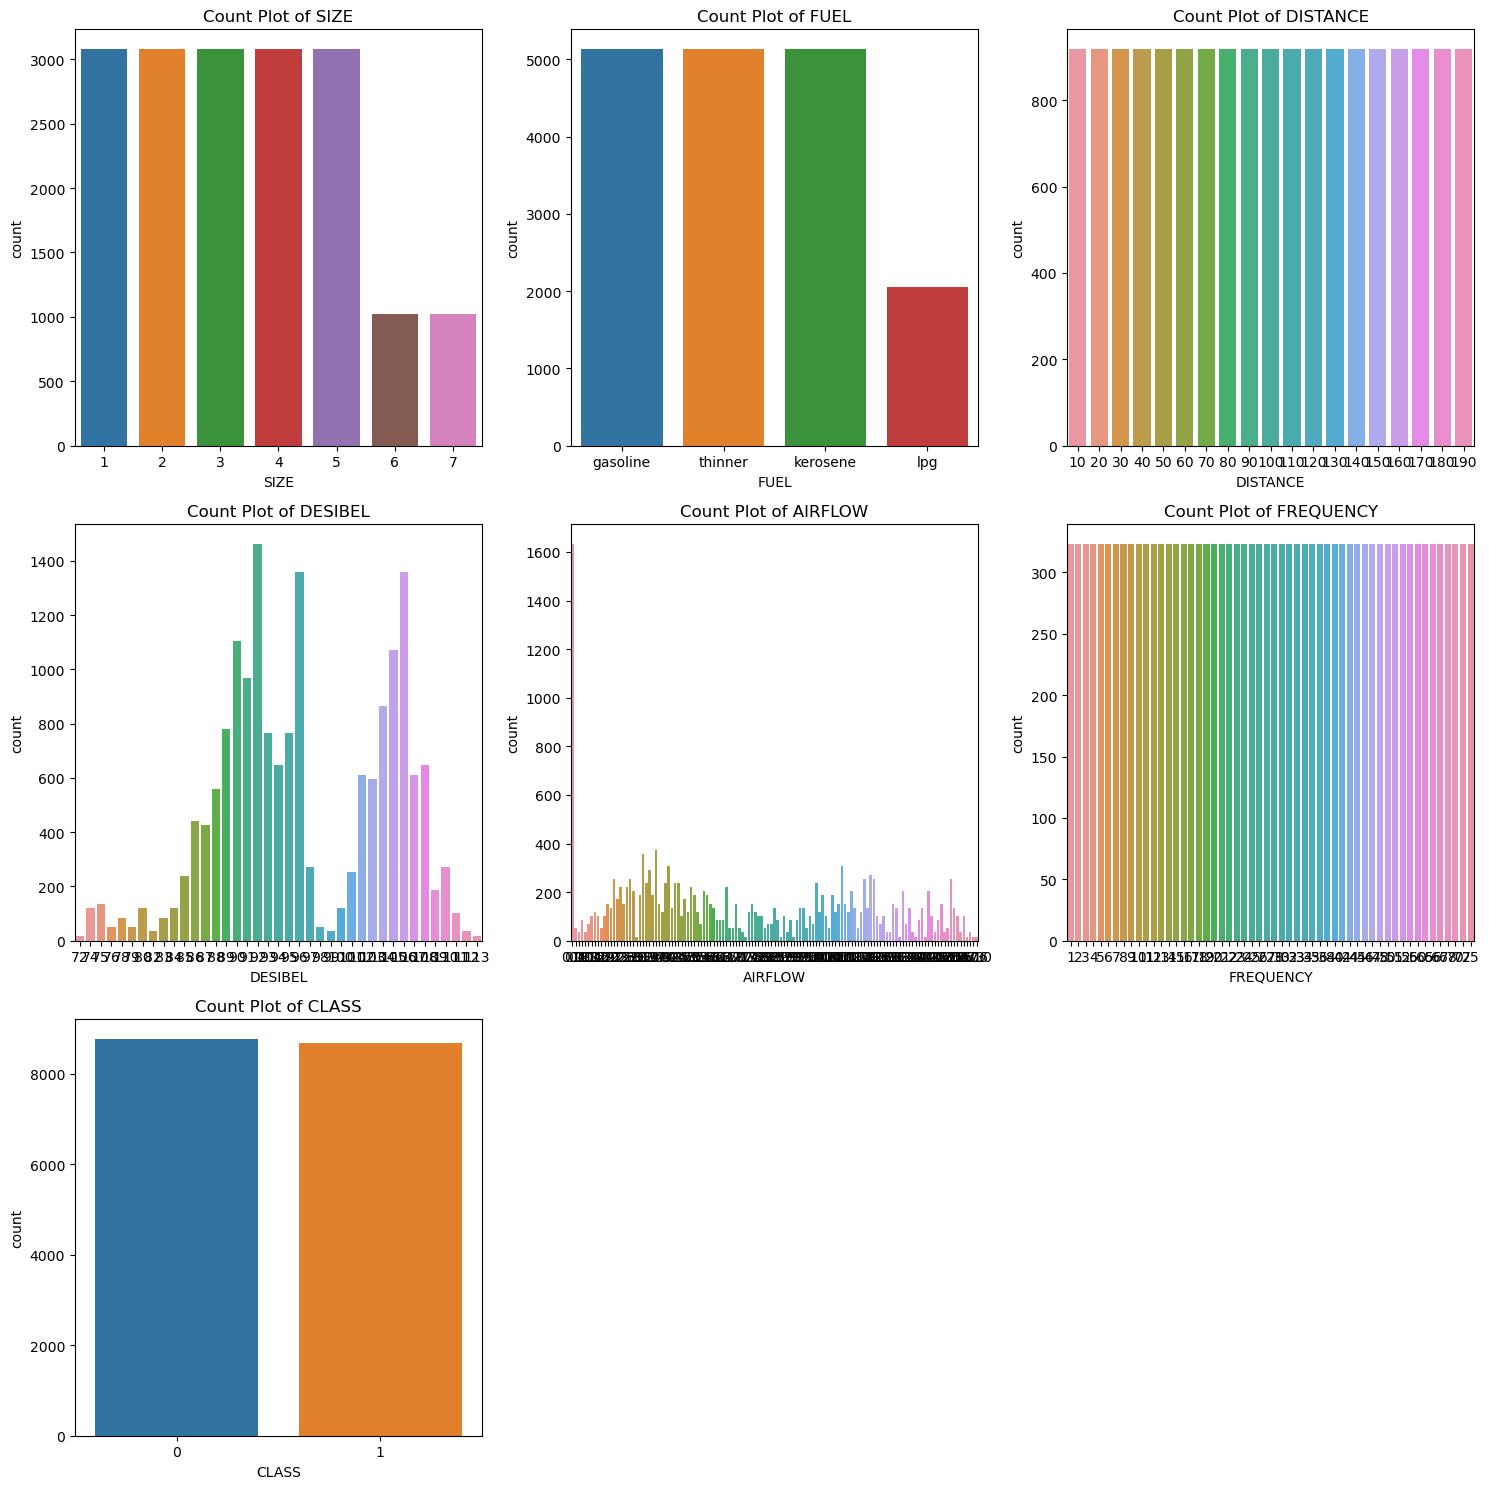

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure
fig = plt.figure(figsize=(15, 15))  # Adjust the figure size as needed

# Iterate over each column and create a count plot in a subplot
for i, col in enumerate(data.columns):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=data)
    plt.title(f'Count Plot of {col}')

# Show the plot
plt.tight_layout()
plt.show()



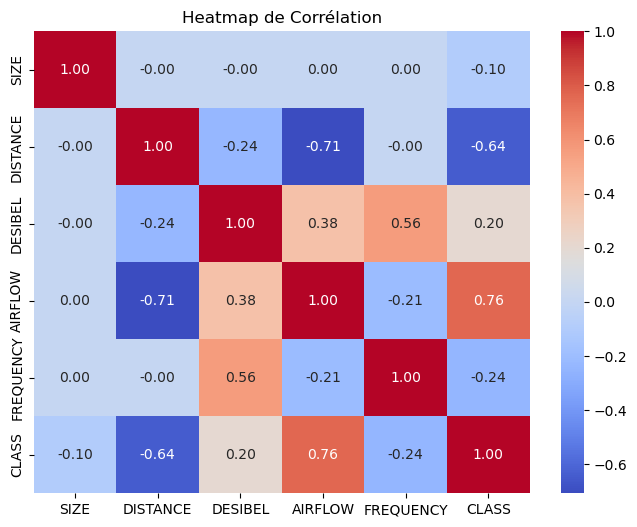

In [8]:
#correlatioon
correlation_matrix = data.corr(numeric_only=True)

# Créer un heatmap avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap de Corrélation")
plt.show()

In [9]:
# Visualiser quelques lignes
data.head()

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,CLASS
0,1,gasoline,10,96,0.0,75,0
1,1,gasoline,10,96,0.0,72,1
2,1,gasoline,10,96,2.6,70,1
3,1,gasoline,10,96,3.2,68,1
4,1,gasoline,10,109,4.5,67,1


# Pretraitement

### Definir pipeline

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


#Remplacer size avec valeur réelle
def replace_size(data):
    return data["SIZE"].map({1: 7, 2: 12, 3: 14, 4: 16, 5: 20, 6: 0, 7: 1}).to_frame()

#Encodage fuel
def replace_fuel(data):
    return data["FUEL"].map({"gasoline": 0, "thinner": 1, "kerosene": 2, "lpg": 3}).to_frame()

preprocessor = ColumnTransformer(
        transformers=[
            ('replace_size', FunctionTransformer(replace_size), ['SIZE']),
            ('replace_fuel', FunctionTransformer(replace_fuel), ['FUEL'])
        ],
    remainder='passthrough'
)


# Definir pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100))
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('replace_size',
                                                  FunctionTransformer(func=<function replace_size at 0x000001FE547A14E0>),
                                                  ['SIZE']),
                                                 ('replace_fuel',
                                                  FunctionTransformer(func=<function replace_fuel at 0x000001FE55F3E160>),
                                                  ['FUEL'])])),
                ('classifier', RandomForestClassifier())])

### Fitting et evaluation du modele

Accuracy: 0.9670392662654056


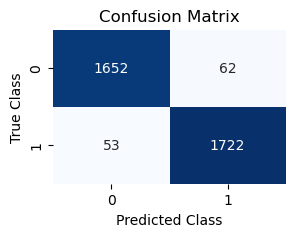

In [11]:
# Splitting the dataframe into features (X) and target variable (y)
X = data.drop(columns=['CLASS'])  # Replace 'target_column' with the name of your target column
y = data['CLASS']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model using pipeline
pipeline.fit(X_train, y_train)

# Evaluate the model
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Compute and plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3, 2))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

### Enregistrement du pipeline dans un fichier pickle

In [12]:
import pickle

# Save the pipeline to a pickle file
with open('pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

# Interface de prediction

In [13]:
import tkinter as tk
from tkinter import ttk
import pickle

with open('pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

def predict():
    fuel = combo_fuel.get()
    if fuel == 'LPG':
        size_option = combo_fuel_lpg.get().split('=')[-1]
        # Map "Full throttle" to 7 and "Half throttle" to 6
        size = 1 if size_option == 'Full throttle setting' else 0
    else:
        size = int(entry_size.get())
    fuel_mapping = {'Gasoline': 0, 'Thinner': 1, 'Kerosene': 2, 'LPG': 3}
    fuel = fuel_mapping.get(fuel, -1)
    distance = int(entry_distance.get())
    desibel = int(entry_desibel.get())
    airflow = float(entry_airflow.get())
    frequency = int(entry_frequency.get())
    
    # Predict class
    prediction = pipeline.named_steps['classifier'].predict([[size, fuel, distance, desibel, airflow, frequency]])

    
    if prediction[0] == 0:
        result = "Non extinct"
    elif prediction[0] == 1:
        result = "Extinct"
    else:
        pass
    # Display the predicted class
    predicted_class_label.config(text="Predicted Class: " + result)

def validate_input(input):
    # Function to allow only numerical input
    if input.isdigit() or (input.startswith('-') and input[1:].isdigit()):
        return True
    elif input == "":
        return True
    else:
        return False

def toggle_fuel_input(event=None):
    if combo_fuel.get() == 'LPG':
        entry_size.grid_forget()
        label_size.grid_forget()
        label_fuel_lpg.grid(row=1, column=0, sticky="w", padx=5, pady=5)
        combo_fuel_lpg.grid(row=1, column=1, padx=5, pady=5)
    else:
        combo_fuel_lpg.grid_forget()
        label_fuel_lpg.grid_forget()
        label_size.grid(row=1, column=0, sticky="w", padx=5, pady=5)
        entry_size.grid(row=1, column=1, padx=5, pady=5)

# Create main window
window = tk.Tk()
window.title("Prediction d'extinction")

# Création des composants du formulaire
fuel_values = ['Gasoline', 'Kerosene', 'Thinner', 'LPG']
label_fuel = tk.Label(window, text="Fuel:")
combo_fuel = ttk.Combobox(window, values=fuel_values, state='readonly')
combo_fuel.set("Gasoline")  # Set default value to Gasoline
combo_fuel.bind("<<ComboboxSelected>>", toggle_fuel_input)

label_size = tk.Label(window, text="Size in cm:")
entry_size = tk.Entry(window, validate="key", validatecommand=(window.register(validate_input), "%P"))

size_values_lpg = ['Full throttle setting', 'Half throttle setting']
label_fuel_lpg = tk.Label(window, text="LPG flow:")
combo_fuel_lpg = ttk.Combobox(window, values=size_values_lpg, state='readonly')
combo_fuel_lpg.set("Full throttle setting")  # Set default value to Full throttle

label_distance = tk.Label(window, text="Distance in cm:")
entry_distance = tk.Entry(window, validate="key", validatecommand=(window.register(validate_input), "%P"))

label_desibel = tk.Label(window, text="Decibel in db:")
entry_desibel = tk.Entry(window, validate="key", validatecommand=(window.register(validate_input), "%P"))

label_airflow = tk.Label(window, text="Airflow in m/s:")
entry_airflow = tk.Entry(window, validate="key", validatecommand=(window.register(validate_input), "%P"))

label_frequency = tk.Label(window, text="Frequency in Hz:")
entry_frequency = tk.Entry(window, validate="key", validatecommand=(window.register(validate_input), "%P"))

# Button to trigger prediction
predict_button = tk.Button(window, text="Predict", command=predict)

# Label to display predicted class
predicted_class_label = tk.Label(window, text="Predicted Class: ")

# Layout using grid
label_fuel.grid(row=0, column=0, sticky="w", padx=5, pady=5)
combo_fuel.grid(row=0, column=1, padx=5, pady=5)
label_size.grid(row=1, column=0, sticky="w", padx=5, pady=5)
entry_size.grid(row=1, column=1, padx=5, pady=5)
label_distance.grid(row=2, column=0, sticky="w", padx=5, pady=5)
entry_distance.grid(row=2, column=1, padx=5, pady=5)
label_desibel.grid(row=3, column=0, sticky="w", padx=5, pady=5)
entry_desibel.grid(row=3, column=1, padx=5, pady=5)
label_airflow.grid(row=4, column=0, sticky="w", padx=5, pady=5)
entry_airflow.grid(row=4, column=1, padx=5, pady=5)
label_frequency.grid(row=5, column=0, sticky="w", padx=5, pady=5)
entry_frequency.grid(row=5, column=1, padx=5, pady=5)
predict_button.grid(row=6, columnspan=2, pady=10)
predicted_class_label.grid(row=7, columnspan=2, pady=5)

window.mainloop()